Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


prompt len = 44, completion len = 183
logps  : (183,)
hidden : (183, 1024)
trajectory PPL = 2.648


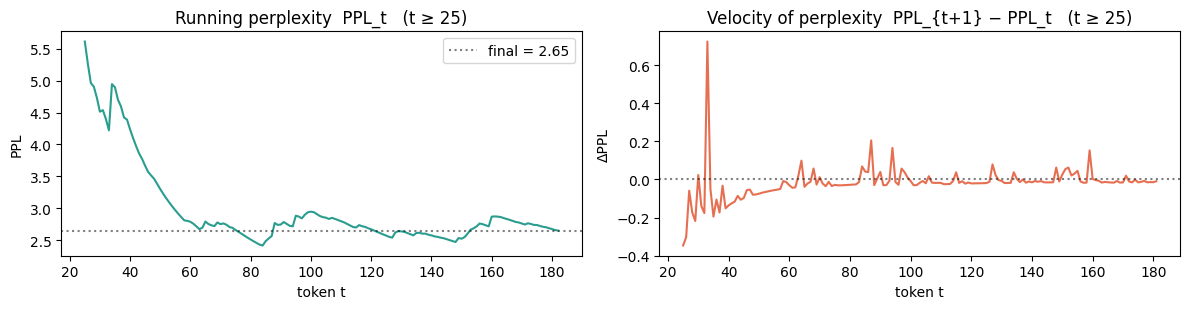

In [6]:
# On Qwen3-0.6B
# perplexity & perplexity velocity
# MBE & MBE velocity
#
# This notebook computes four quantities on a single FIXED trajectory
# (no sampling, fully reproducible):
#   (1) Trajectory perplexity     PPL_t = exp(- (1/t) * Σ_{s≤t} log p_θ(o_s | q, o_<s))
#   (2) Velocity of PPL           v_PPL[t] = PPL_{t+1} − PPL_t
#   (3) Trajectory MBE            matrix-based α=2 Rényi entropy of stacked hidden states
#                                 MBE(Z) = 2 log tr(G) − log ‖G‖_F^2,  G = Z^T Z
#   (4) Velocity of MBE           v_MBE[t] = MBE_{t+1} − MBE_t   (running, computed online)
# ─────────────────────────────────────────────────────────────────────────────

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME   = "Qwen/Qwen3-0.6B"
HIDDEN_LAYER = -1   # which transformer block's hidden state to use for MBE (−1 = last)
WARMUP       = 25    # skip the first few tokens in plots: PPL_t and MBE_t are dominated
                    # by tiny denominators (1/t, single-row Gram) and not informative there.

tok   = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16, output_hidden_states=True
).to(DEVICE).eval()

# ─── 1. Hardcoded prompt + completion (no generation) ───────────────────────
PROMPT = (
    "Use the four numbers 4, 7, 8, 8 exactly once with +, -, *, / and parentheses "
    "to make 24. Show your reasoning step by step, then give the final expression."
)
COMPLETION = (
    "Let me try (8 - 4) * (8 - 7) first: that gives 4 * 1 = 4, which is too small. "
    "Try (8 + 4) * (8 - 7) = 12 * 1 = 12, still too small. "
    "Try 8 * (7 - 4) = 8 * 3 = 24. But I have not used the second 8. "
    "Try 8 / 8 = 1, then 4 * 7 = 28, and 28 - 1 = 27. Close but not 24. "
    "Try (8 + 8) * (7 - 4) / 2: not allowed, no 2. "
    "Final answer: 8 * (7 - 4) + 8 - 8 = 24."
)

prompt_ids     = tok(PROMPT,     return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
completion_ids = tok(COMPLETION, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
full_ids       = torch.cat([prompt_ids, completion_ids], dim=1)            # (1, P+T)
P, T           = prompt_ids.shape[1], completion_ids.shape[1]
print(f"prompt len = {P}, completion len = {T}")

# ─── 2. Single forward pass: per-token logps + per-token hidden states ──────
@torch.no_grad()
def forward_with_logps_and_hidden(model, full_ids, prompt_len):
    """
    Returns
        logps  : (T,)    log p_θ(o_t | q, o_<t)  for t = 1..T
        hidden : (T, D)  hidden state at each completion-token position
    """
    out    = model(full_ids, output_hidden_states=True, use_cache=False)
    logits = out.logits[0]                       # (P+T, V)
    h_all  = out.hidden_states[HIDDEN_LAYER][0]  # (P+T, D)

    # logits at position i predict token i+1, so completion token at index
    # (prompt_len + t) is scored by logits at (prompt_len + t - 1).
    score_logits = logits[prompt_len - 1 : -1]                              # (T, V)
    targets      = full_ids[0, prompt_len:]                                 # (T,)
    logps        = torch.log_softmax(score_logits.float(), dim=-1)
    logps        = logps.gather(-1, targets.unsqueeze(-1)).squeeze(-1)      # (T,)

    hidden = h_all[prompt_len:].float()                                     # (T, D)
    return logps.cpu(), hidden.cpu()

logps, hidden = forward_with_logps_and_hidden(model, full_ids, P)
print(f"logps  : {tuple(logps.shape)}")
print(f"hidden : {tuple(hidden.shape)}")


# ─── 3. Perplexity & velocity of perplexity ─────────────────────────────────
def trajectory_ppl(logps: torch.Tensor) -> float:
    """PPL of the whole trajectory: exp(- mean_t log p(o_t|...))."""
    return torch.exp(-logps.mean()).item()

def running_ppl(logps: torch.Tensor) -> torch.Tensor:
    """PPL_t for t=1..T, where PPL_t = exp(- (1/t) * Σ_{s≤t} logp_s)."""
    cum = torch.cumsum(logps, dim=0)
    t   = torch.arange(1, len(logps) + 1, dtype=cum.dtype)
    return torch.exp(-cum / t)                     # (T,)

def velocity_of_ppl(logps: torch.Tensor) -> torch.Tensor:
    """v_PPL[t] = PPL_{t+1} − PPL_t.  Length T−1."""
    ppl = running_ppl(logps)
    return ppl[1:] - ppl[:-1]

ppl_T   = trajectory_ppl(logps)
ppl_run = running_ppl(logps)
v_ppl   = velocity_of_ppl(logps)
print(f"trajectory PPL = {ppl_T:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].plot(np.arange(WARMUP, len(ppl_run)), ppl_run[WARMUP:].numpy(), color="#2a9d8f")
ax[0].axhline(ppl_T, ls=":", color="k", alpha=.5, label=f"final = {ppl_T:.2f}")
ax[0].set_title(f"Running perplexity  PPL_t   (t ≥ {WARMUP})"); ax[0].set_xlabel("token t"); ax[0].set_ylabel("PPL"); ax[0].legend()
ax[1].plot(np.arange(WARMUP, len(v_ppl)), v_ppl[WARMUP:].numpy(), color="#e76f51")
ax[1].axhline(0, ls=":", color="k", alpha=.5)
ax[1].set_title(f"Velocity of perplexity  PPL_{{t+1}} − PPL_t   (t ≥ {WARMUP})"); ax[1].set_xlabel("token t"); ax[1].set_ylabel("ΔPPL")
plt.tight_layout(); plt.show()


trajectory MBE = 1.0350    (running MBE at t=T = 1.0350)


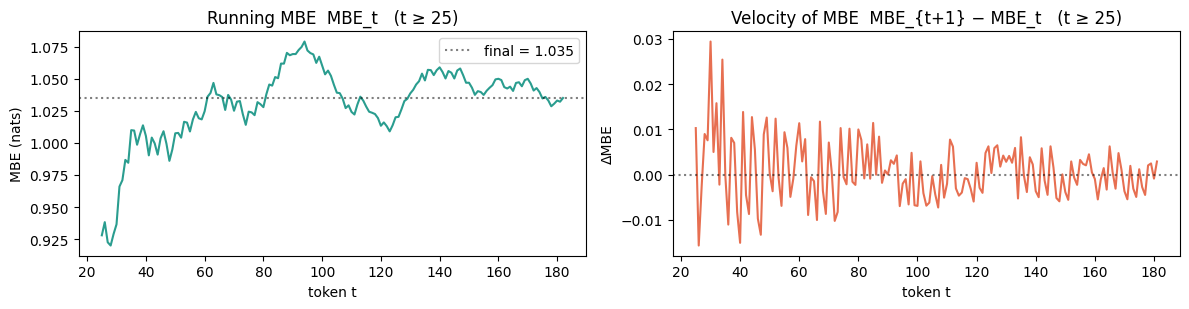

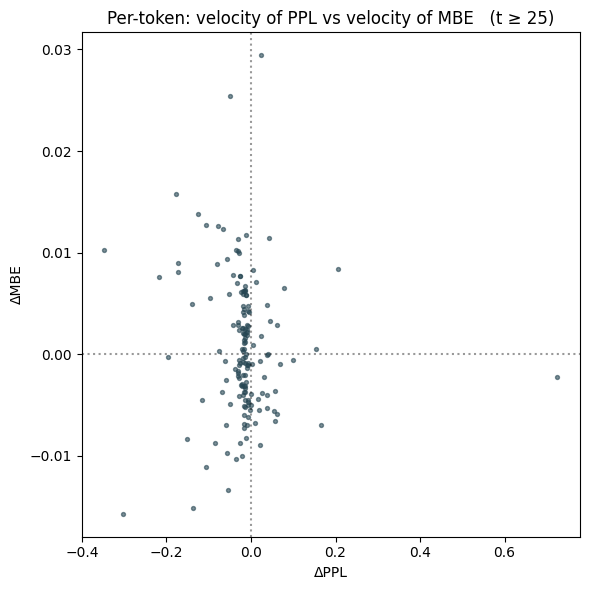

Pearson r(ΔPPL, ΔMBE) = -0.080


In [7]:
# ─── 4. MBE & velocity of MBE ───────────────────────────────────────────────
#
# MBE(Z)  = 2 log tr(G) − log ‖G‖_F^2,   G = Z^T Z   ∈ ℝ^{D×D}
#
# Trajectory MBE      : MBE applied to Z = stacked hidden states of all T tokens.
# Running MBE_t       : MBE applied to Z_t = first t hidden states.
#                       Computed online: G_t = G_{t-1} + h_t h_t^T, no recompute.
# Velocity of MBE     : v_MBE[t] = MBE_{t+1} − MBE_t.
#
# Note: MBE(Z) for a single row is 0 (trivial), so MBE_t is meaningful only for t ≥ 2.

def mbe_reverse_gram(Z, epsilon=1e-5):
    """MBE via reverse Gram matrix Z^T Z (D×D instead of N×N). Memory-efficient when N >> D."""
    Z = Z.float()
    G = torch.bmm(Z.transpose(1, 2), Z)  # (B, D, D)
    gram_trace = torch.diagonal(G, dim1=1, dim2=2).sum(dim=1)
    gram_sq = G.pow(2).sum(dim=(1, 2))
    log_trace = torch.log(gram_trace.abs() + epsilon)
    log_sq = torch.log(gram_sq + epsilon)
    mbe = 2 * log_trace - log_sq
    return mbe.clamp(min=0.0)

def trajectory_mbe(hidden: torch.Tensor) -> float:
    """MBE on the full (T, D) hidden-state matrix."""
    Z = hidden.unsqueeze(0).float()           # (1, T, D)
    return mbe_reverse_gram(Z).item()

def running_mbe(hidden: torch.Tensor, eps: float = 1e-5) -> torch.Tensor:
    """
    MBE_t for t = 1..T, computed online via running G_t = Σ_{s≤t} h_s h_s^T.

    Avoids the O(T·D²) recompute that a naive loop over `mbe_reverse_gram` would do.
    """
    Z = hidden.float()                        # (T, D)
    T_, D = Z.shape
    G = torch.zeros(D, D, dtype=Z.dtype)
    out = torch.empty(T_, dtype=Z.dtype)
    for t in range(T_):
        h = Z[t:t+1]                          # (1, D)
        G = G + h.T @ h                       # (D, D)
        tr   = torch.trace(G)
        sqfr = G.pow(2).sum()
        out[t] = (2.0 * torch.log(tr.abs() + eps) - torch.log(sqfr + eps)).clamp(min=0.0)
    return out                                # (T,)

def velocity_of_mbe(hidden: torch.Tensor) -> torch.Tensor:
    """v_MBE[t] = MBE_{t+1} − MBE_t.  Length T−1."""
    mbe = running_mbe(hidden)
    return mbe[1:] - mbe[:-1]

mbe_T   = trajectory_mbe(hidden)
mbe_run = running_mbe(hidden)
v_mbe   = velocity_of_mbe(hidden)
print(f"trajectory MBE = {mbe_T:.4f}    (running MBE at t=T = {mbe_run[-1].item():.4f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].plot(np.arange(WARMUP, len(mbe_run)), mbe_run[WARMUP:].numpy(), color="#2a9d8f")
ax[0].axhline(mbe_T, ls=":", color="k", alpha=.5, label=f"final = {mbe_T:.3f}")
ax[0].set_title(f"Running MBE  MBE_t   (t ≥ {WARMUP})"); ax[0].set_xlabel("token t"); ax[0].set_ylabel("MBE (nats)"); ax[0].legend()
ax[1].plot(np.arange(WARMUP, len(v_mbe)), v_mbe[WARMUP:].numpy(), color="#e76f51")
ax[1].axhline(0, ls=":", color="k", alpha=.5)
ax[1].set_title(f"Velocity of MBE  MBE_{{t+1}} − MBE_t   (t ≥ {WARMUP})"); ax[1].set_xlabel("token t"); ax[1].set_ylabel("ΔMBE")
plt.tight_layout(); plt.show()


# ─── 5. Joint view: PPL-velocity vs MBE-velocity ────────────────────────────
# Whether they correlate is itself an empirical question worth looking at.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(v_ppl[WARMUP:].numpy(), v_mbe[WARMUP:].numpy(), s=8, alpha=.6, color="#264653")
ax.axhline(0, ls=":", color="k", alpha=.4); ax.axvline(0, ls=":", color="k", alpha=.4)
ax.set_xlabel("ΔPPL"); ax.set_ylabel("ΔMBE")
ax.set_title(f"Per-token: velocity of PPL vs velocity of MBE   (t ≥ {WARMUP})")
plt.tight_layout(); plt.show()

corr = np.corrcoef(v_ppl[WARMUP:].numpy(), v_mbe[WARMUP:].numpy())[0, 1]
print(f"Pearson r(ΔPPL, ΔMBE) = {corr:+.3f}")
